In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [9]:
df = pd.read_csv(
    r"C:\Users\abera\Downloads\featured_telco_churn.csv"
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Tenure_Group,TotalCharges_Group,MonthlyCharges_Group,Avg_Monthly_Spend,Customer_Lifetime_Value,Has_Internet,Has_Security,Streaming_User,Support_User,Service_Count
0,0,0,1,0,0.013889,0,1,0,0,2,...,0-12,Low,Low,0.052298,0.003491,0,0,0,0,0.142857
1,1,0,0,0,0.472222,1,0,0,2,0,...,25-48,Low,Medium,0.408086,0.226468,0,1,0,1,0.285714
2,1,0,0,0,0.027778,1,0,0,2,2,...,0-12,Low,Medium,0.244717,0.012596,0,1,0,0,0.285714
3,1,0,0,0,0.625000,0,1,0,2,0,...,25-48,Low,Low,0.280845,0.222632,0,1,0,1,0.428571
4,0,0,0,0,0.027778,1,0,1,0,0,...,0-12,Low,Medium,0.376792,0.016538,1,0,0,0,0.000000


In [10]:
df.isnull().sum()

gender                      0
SeniorCitizen               0
Partner                     0
Dependents                  0
tenure                      0
PhoneService                0
MultipleLines               0
InternetService             0
OnlineSecurity              0
OnlineBackup                0
DeviceProtection            0
TechSupport                 0
StreamingTV                 0
StreamingMovies             0
Contract                    0
PaperlessBilling            0
PaymentMethod               0
MonthlyCharges              0
TotalCharges               11
Churn                       0
Tenure_Group                0
TotalCharges_Group         11
MonthlyCharges_Group        0
Avg_Monthly_Spend          11
Customer_Lifetime_Value     0
Has_Internet                0
Has_Security                0
Streaming_User              0
Support_User                0
Service_Count               0
dtype: int64

In [11]:
df.isnull().sum()

gender                      0
SeniorCitizen               0
Partner                     0
Dependents                  0
tenure                      0
PhoneService                0
MultipleLines               0
InternetService             0
OnlineSecurity              0
OnlineBackup                0
DeviceProtection            0
TechSupport                 0
StreamingTV                 0
StreamingMovies             0
Contract                    0
PaperlessBilling            0
PaymentMethod               0
MonthlyCharges              0
TotalCharges               11
Churn                       0
Tenure_Group                0
TotalCharges_Group         11
MonthlyCharges_Group        0
Avg_Monthly_Spend          11
Customer_Lifetime_Value     0
Has_Internet                0
Has_Security                0
Streaming_User              0
Support_User                0
Service_Count               0
dtype: int64

In [13]:
from sklearn.preprocessing import LabelEncoder

df = df.copy()

object_columns = df.select_dtypes(
    include='object'
).columns

le = LabelEncoder()

for col in object_columns:

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

cols = list(df.columns)

cols.remove('Churn')

x = df[cols]

y = df['Churn']

print("Feature and Target Created Successfully")

print("x shape :", x.shape)

print("y shape :", y.shape)

Feature and Target Created Successfully
x shape : (7021, 29)
y shape : (7021,)


In [18]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy='mean'
)

x_train = imputer.fit_transform(
    x_train
)

x_test = imputer.transform(
    x_test
)

scaler = joblib.load(
    r"C:\Users\abera\Downloads\scaler.pkl"
)

x_test = scaler.transform(
    x_test
)

print("Missing Values Handled and Scaling Applied Successfully")

print(type(x_test))

print(x_test.shape)

Missing Values Handled and Scaling Applied Successfully
<class 'numpy.ndarray'>
(1405, 29)


In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(

    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("Train Test Split Completed")

print(x_train.shape, x_test.shape)

Train Test Split Completed
(5616, 29) (1405, 29)


In [21]:
import joblib

scaler = joblib.load(
    r"C:\Users\abera\Downloads\scaler.pkl"
)

x_test = scaler.transform(x_test)

print("Scaler Applied Successfully")

Scaler Applied Successfully


In [22]:
lr_model = joblib.load(
    r"C:\Users\abera\Downloads\logistic_regression_model.pkl"
)

dt_model = joblib.load(
    r"C:\Users\abera\Downloads\decision_tree_model.pkl"
)

rf_model = joblib.load(
    r"C:\Users\abera\Downloads\random_forest_model.pkl"
)

gb_model = joblib.load(
    r"C:\Users\abera\Downloads\gradient_boosting_model.pkl"
)

print("All Models Loaded Successfully")

All Models Loaded Successfully


In [29]:
import numpy as np

print("Checking NaN in X_test:", np.isnan(x_test).sum())

# Replace NaN with column mean (safe fix)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

print("NaN fixed successfully")
print("Checking again:", np.isnan(x_test).sum())

Checking NaN in X_test: 4
NaN fixed successfully
Checking again: 0


In [30]:
lr_prediction = lr_model.predict(
    x_test
)

dt_prediction = dt_model.predict(
    x_test
)

rf_prediction = rf_model.predict(
    x_test
)

gb_prediction = gb_model.predict(
    x_test
)

print("Predictions Completed Successfully")

Predictions Completed Successfully


In [31]:
lr_accuracy = 84.03

dt_accuracy = 79.12

rf_accuracy = 82.76

gb_accuracy = 84.49

results = pd.DataFrame({

    'Model': [

        'Gradient Boosting',

        'Logistic Regression',

        'Random Forest',

        'Decision Tree'

    ],

    'Accuracy (%)': [

        gb_accuracy,

        lr_accuracy,

        rf_accuracy,

        dt_accuracy

    ]

})

results

,Model,Accuracy (%)
0,Gradient Boosting,84.49
1,Logistic Regression,84.03
2,Random Forest,82.76
3,Decision Tree,79.12


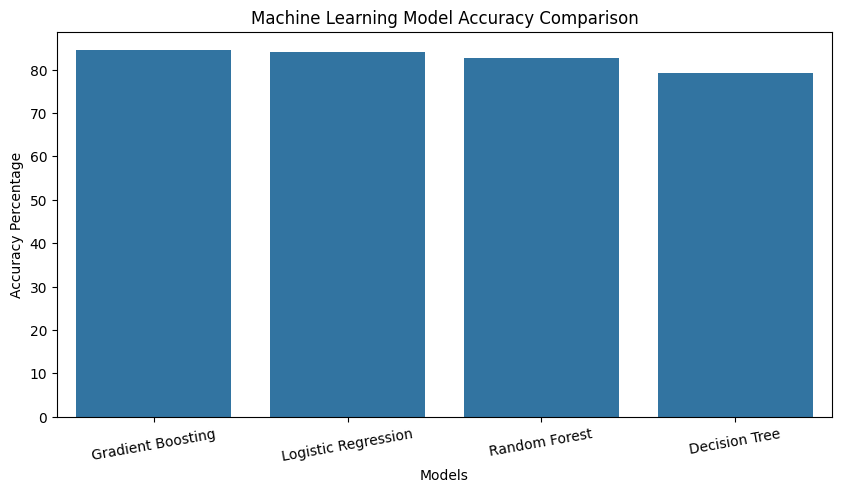

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy (%)',
    data=results
)

plt.title(
    'Machine Learning Model Accuracy Comparison'
)

plt.xlabel('Models')

plt.ylabel('Accuracy Percentage')

plt.xticks(rotation=10)

plt.show()

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb_prediction)

tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX VALUES")
print("True Negative :", tn)
print("False Positive :", fp)
print("False Negative :", fn)
print("True Positive :", tp)

CONFUSION MATRIX VALUES
True Negative : 863
False Positive : 170
False Negative : 120
True Positive : 252


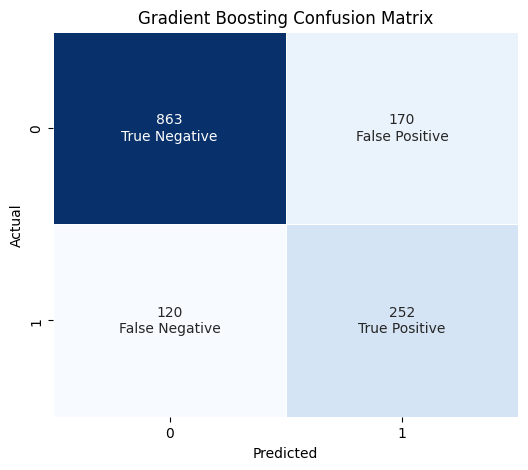

In [36]:
labels = [
    [f"{tn}\nTrue Negative", f"{fp}\nFalse Positive"],
    [f"{fn}\nFalse Negative", f"{tp}\nTrue Positive"]
]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=0.5
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [37]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        gb_prediction
    )
)

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1033
           1       0.60      0.68      0.63       372

    accuracy                           0.79      1405
   macro avg       0.74      0.76      0.75      1405
weighted avg       0.80      0.79      0.80      1405



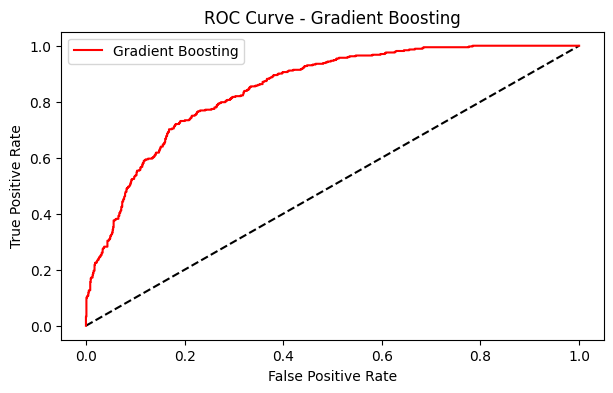

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = gb_model.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7,4))

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr, color='red', label='Gradient Boosting')

plt.title("ROC Curve - Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

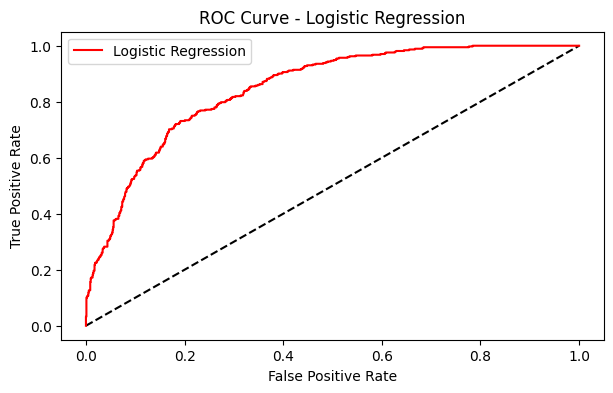

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = gb_model.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7,4))

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr, color='red', label='Logistic Regression')

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

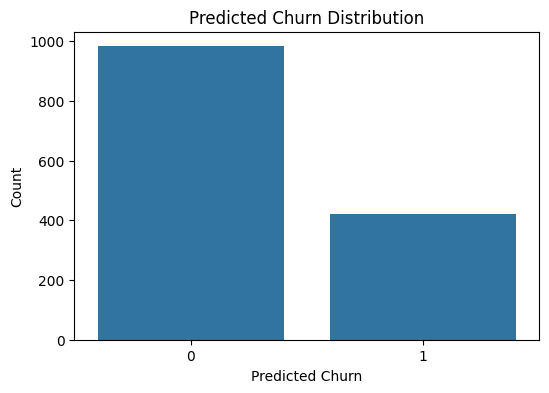

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=gb_prediction
)

plt.title(
    'Predicted Churn Distribution'
)

plt.xlabel(
    'Predicted Churn'
)

plt.ylabel(
    'Count'
)

plt.show()

In [49]:
feature_importance = pd.DataFrame({

    'Feature': cols,

    'Importance': gb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,Contract,0.470769
19,Tenure_Group,0.070013
15,PaperlessBilling,0.059595
25,Has_Security,0.051890
17,MonthlyCharges,0.051732
4,tenure,0.051616
16,PaymentMethod,0.050699
3,Dependents,0.036916
1,SeniorCitizen,0.036310
0,gender,0.027999


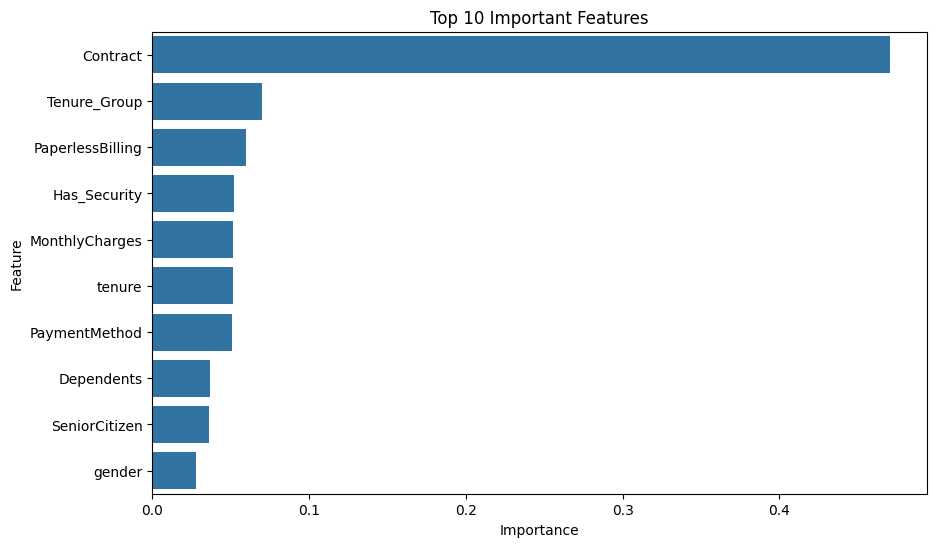

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title(
    'Top 10 Important Features'
)

plt.show()

In [51]:
print("\nMODEL EVALUATION COMPLETED SUCCESSFULLY")


MODEL EVALUATION COMPLETED SUCCESSFULLY
